In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/processed_data.csv")

In [5]:
print(df.head())


   sex  agegrp  rowtotal_17  rowtotal_18  rowtotal_20  high_illiteracy_risk  \
0    1       5          144          134          144                     1   
1    1       6          132          129          132                     1   
2    1       7          122          119          122                     1   
3    1       8          113          107          113                     1   
4    1       9          127          125          127                     0   

   early_edu_rate  primary_rate  secondary_rate  slc_rate  ...  \
0        1.000000      0.000000             0.0       0.0  ...   
1        0.147287      0.852713             0.0       0.0  ...   
2        0.042017      0.957983             0.0       0.0  ...   
3        0.028037      0.971963             0.0       0.0  ...   
4        0.000000      1.000000             0.0       0.0  ...   

   attending_rate  ever_attending_rate  never_attending_rate  prov_1  prov_2  \
0        0.930556             0.000000          

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17824 entries, 0 to 17823
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   17824 non-null  int64  
 1   agegrp                17824 non-null  int64  
 2   rowtotal_17           17824 non-null  int64  
 3   rowtotal_18           17824 non-null  int64  
 4   rowtotal_20           17824 non-null  int64  
 5   high_illiteracy_risk  17824 non-null  int64  
 6   early_edu_rate        17824 non-null  float64
 7   primary_rate          17824 non-null  float64
 8   secondary_rate        17824 non-null  float64
 9   slc_rate              17824 non-null  float64
 10  no_education_rate     17824 non-null  float64
 11  attending_rate        17824 non-null  float64
 12  ever_attending_rate   17824 non-null  float64
 13  never_attending_rate  17824 non-null  float64
 14  prov_1                17824 non-null  bool   
 15  prov_2             

In [7]:
print(df.columns)

Index(['sex', 'agegrp', 'rowtotal_17', 'rowtotal_18', 'rowtotal_20',
       'high_illiteracy_risk', 'early_edu_rate', 'primary_rate',
       'secondary_rate', 'slc_rate', 'no_education_rate', 'attending_rate',
       'ever_attending_rate', 'never_attending_rate', 'prov_1', 'prov_2',
       'prov_3', 'prov_4', 'prov_5', 'prov_6', 'prov_7'],
      dtype='object')


In [8]:
X = df.drop(["high_illiteracy_risk","never_attending_rate"], axis=1)
y = df["high_illiteracy_risk"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test_scaled)

In [13]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}\n")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:  0.9388
Precision: 0.9738
Recall:    0.9014
F1-Score:  0.9362

Confusion Matrix:
 [[1747   43]
 [ 175 1600]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94      1790
           1       0.97      0.90      0.94      1775

    accuracy                           0.94      3565
   macro avg       0.94      0.94      0.94      3565
weighted avg       0.94      0.94      0.94      3565



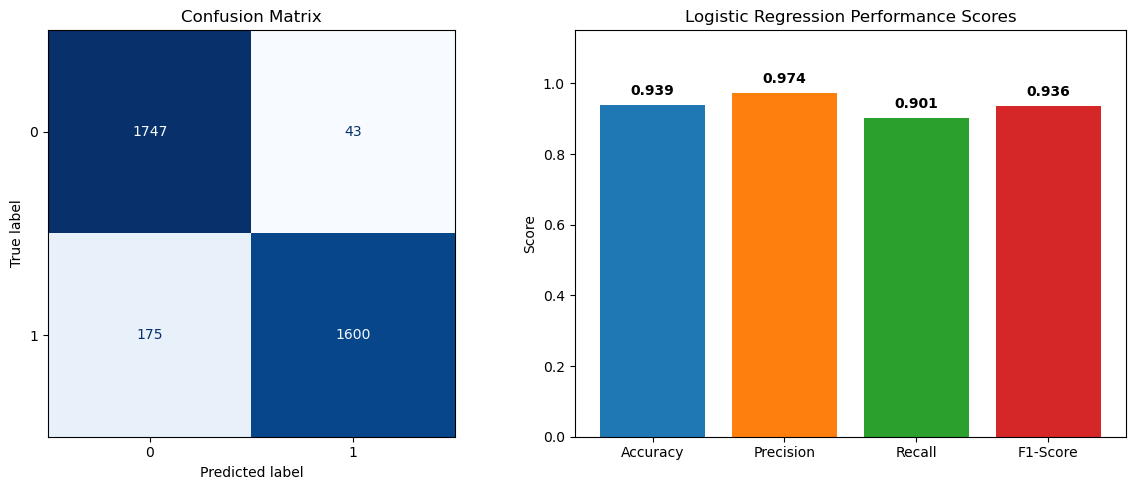

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# 2. Performance Metrics Bar Chart
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_values = [acc, prec, rec, f1]
bars = axes[1].bar(
    metrics_names, metrics_values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Score")
axes[1].set_title("Logistic Regression Performance Scores")

# Add exact numeric values above each bar
for bar, val in zip(bars, metrics_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()